# Experiment 003 — Feature Engineering

**Goal:** Test whether engineered features improve on the exp_002 best result (Random Undersampling, selected by F1 on Survived).

**Baseline to beat (exp_002 Random Undersampling):** TBD after running exp_002

**Changes from exp_002:**
- Same base preprocessing (impute, encode, scale)
- Same imbalance method: Random Undersampling (best from exp_002)
- New features added:
  1. `LogFare` — log1p of raw Fare (handles right skew)
  2. `AgeGroup` — Child (<16) / Adult (16–60) / Senior (>60) binning; encodes "women and children first" directly
  3. `FamilySize` — SibSp + Parch + 1
  4. `IsAlone` — 1 if FamilySize == 1
  5. `Pclass_x_Fare` — interaction term
  6. `FarePerPerson` — Fare / FamilySize (normalises shared-ticket fares)
  7. Title grouping — rare titles collapsed to 'Rare'
- `Ticket_is_numeric` dropped (weak SHAP signal from exp_001)

## 1. Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
import shap

pd.set_option('display.max_columns', None)
%matplotlib inline

## 2. Load & Base Preprocessing (same as exp_001/002)

In [36]:
df = pd.read_csv('../../data/raw/train.csv')
df = df.drop(columns=['PassengerId'])

# Extract helpers from raw columns before dropping them
df['Name_title']        = df['Name'].str.extract(r',\s*([^.]+)\.')
df['Cabin_deck']        = df['Cabin'].str[0]
df['Ticket_is_numeric'] = df['Ticket'].str.match(r'^\d+$')
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

print(f'Shape: {df.shape}')
print(f'Survival rate: {df["Survived"].mean():.2%}')

Shape: (891, 11)
Survival rate: 38.38%


In [37]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 712 | Test: 179


In [38]:
X_train = X_train.copy()
X_test  = X_test.copy()

# Impute (fit on train only)
age_median    = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]

X_train['Age']        = X_train['Age'].fillna(age_median)
X_test['Age']         = X_test['Age'].fillna(age_median)
X_train['Embarked']   = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked']    = X_test['Embarked'].fillna(embarked_mode)
X_train['Cabin_deck'] = X_train['Cabin_deck'].fillna('Unknown')
X_test['Cabin_deck']  = X_test['Cabin_deck'].fillna('Unknown')

print(f'Age imputed with: {age_median} | Embarked imputed with: {embarked_mode!r}')

Age imputed with: 28.5 | Embarked imputed with: 'S'


## 3. Feature Engineering

In [39]:
# --- Title grouping ---
# Rare titles (n<=2) have too few samples to be reliable — collapse to 'Rare'
# Mlle (French Miss) → Miss, Mme (French Mrs) → Mrs for consistency
title_map = {
    'Mlle': 'Miss',
    'Mme':  'Mrs',
    'Ms':   'Miss',
}
common_titles = {'Mr', 'Mrs', 'Miss', 'Master'}

for df_ in [X_train, X_test]:
    df_['Name_title'] = df_['Name_title'].replace(title_map)
    df_['Name_title'] = df_['Name_title'].apply(
        lambda t: t if t in common_titles else 'Rare'
    )

print('Title distribution after grouping:')
print(X_train['Name_title'].value_counts())

Title distribution after grouping:
Name_title
Mr        412
Miss      144
Mrs       107
Master     31
Rare       18
Name: count, dtype: int64


In [40]:
# --- Family features ---
# FamilySize: everyone travelling together including the passenger themselves
# IsAlone: solo travellers had notably lower survival rates
for df_ in [X_train, X_test]:
    df_['FamilySize'] = df_['SibSp'] + df_['Parch'] + 1
    df_['IsAlone']    = (df_['FamilySize'] == 1).astype(int)

print('FamilySize distribution:')
print(X_train['FamilySize'].value_counts().sort_index())
print(f'\nIsAlone rate: {X_train["IsAlone"].mean():.2%}')

FamilySize distribution:
FamilySize
1     434
2     129
3      77
4      22
5      14
6      16
7      11
8       4
11      5
Name: count, dtype: int64

IsAlone rate: 60.96%


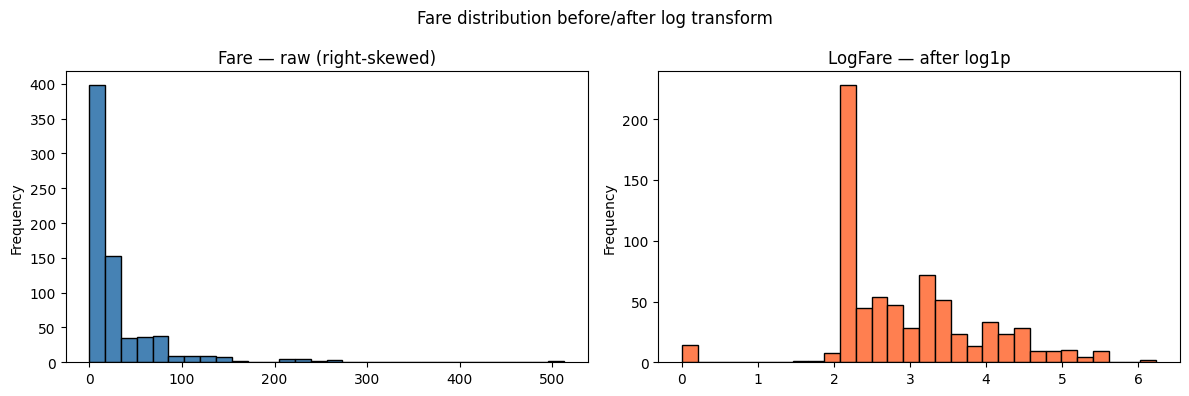

In [41]:
# --- Log transforms ---
# log1p avoids log(0) issues and handles the heavy right skew in Fare
# Age is NOT log-transformed here — binned into groups instead (see next cell)
for df_ in [X_train, X_test]:
    df_['LogFare'] = np.log1p(df_['Fare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X_train['Fare'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Fare — raw (right-skewed)')
X_train['LogFare'].plot(kind='hist', bins=30, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('LogFare — after log1p')
plt.suptitle('Fare distribution before/after log transform')
plt.tight_layout()
plt.show()

In [42]:
# --- Age binning ---
# Bins encode the "women and children first" rule directly as a categorical signal
# Child (<16): prioritised in evacuation
# Adult (16–60): majority of passengers
# Senior (>60): smaller group, lower survival
bins   = [0, 16, 60, np.inf]
labels = ['Child', 'Adult', 'Senior']

for df_ in [X_train, X_test]:
    df_['AgeGroup'] = pd.cut(df_['Age'], bins=bins, labels=labels)

print('AgeGroup distribution (train):')
print(X_train['AgeGroup'].value_counts().sort_index())

# Survival rate by age group (train only — no peeking at test)
surv_by_age = pd.concat([X_train['AgeGroup'], y_train], axis=1)
print('\nSurvival rate by AgeGroup:')
print(surv_by_age.groupby('AgeGroup')['Survived'].mean().round(3))

AgeGroup distribution (train):
AgeGroup
Child      76
Adult     620
Senior     16
Name: count, dtype: int64

Survival rate by AgeGroup:
AgeGroup
Child     0.566
Adult     0.366
Senior    0.188
Name: Survived, dtype: float64


In [43]:
# --- Interaction & ratio features ---
# Pclass_x_Fare: captures 'expensive relative to class' signal
# FarePerPerson: raw Fare is for the whole group on shared tickets — normalise by FamilySize
for df_ in [X_train, X_test]:
    df_['Pclass_x_Fare']   = df_['Pclass'] * df_['Fare']
    df_['FarePerPerson']   = df_['Fare'] / df_['FamilySize']

print('New interaction/ratio features added.')
print(X_train[['Pclass_x_Fare', 'FarePerPerson']].describe().round(2))

New interaction/ratio features added.
       Pclass_x_Fare  FarePerPerson
count         712.00         712.00
mean           51.21          20.40
std            50.20          37.72
min             0.00           0.00
25%            23.69           7.25
50%            28.50           8.45
75%            58.35          20.48
max           512.33         512.33


In [44]:
# --- Drop weak / replaced features ---
# Ticket_is_numeric: weak SHAP signal in exp_001 — drop
# Keep raw SibSp, Parch alongside FamilySize — RF can pick whichever is more useful
for df_ in [X_train, X_test]:
    df_.drop(columns=['Ticket_is_numeric'], inplace=True)

print(f'Features after engineering: {X_train.shape[1]}')
print(list(X_train.columns))

Features after engineering: 15
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Name_title', 'Cabin_deck', 'FamilySize', 'IsAlone', 'LogFare', 'AgeGroup', 'Pclass_x_Fare', 'FarePerPerson']


## 4. Encode & Scale

In [45]:
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck', 'AgeGroup']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'Features after encoding: {X_train.shape[1]}')
print('Total nulls:', X_train.isnull().sum().sum())

Features after encoding: 27
Total nulls: 0


In [46]:
# Scale continuous features — AgeGroup is now categorical (encoded above), not scaled
# Raw Age is kept alongside AgeGroup so the RF can use both
num_scale_cols = ['Age', 'Fare', 'SibSp', 'Parch',
                  'LogFare', 'FamilySize', 'Pclass_x_Fare', 'FarePerPerson']

scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print('Scaled columns:', num_scale_cols)
print(X_train[num_scale_cols].describe().round(3))

Scaled columns: ['Age', 'Fare', 'SibSp', 'Parch', 'LogFare', 'FamilySize', 'Pclass_x_Fare', 'FarePerPerson']
           Age     Fare    SibSp    Parch  LogFare  FamilySize  Pclass_x_Fare  \
count  712.000  712.000  712.000  712.000  712.000     712.000        712.000   
mean     0.000   -0.000   -0.000   -0.000    0.000       0.000          0.000   
std      1.001    1.001    1.001    1.001    1.001       1.001          1.001   
min     -2.238   -0.663   -0.465   -0.466   -3.014      -0.556         -1.021   
25%     -0.581   -0.498   -0.465   -0.466   -0.782      -0.556         -0.549   
50%     -0.081   -0.362   -0.465   -0.466   -0.218      -0.556         -0.453   
75%      0.495   -0.017    0.478   -0.466    0.526       0.073          0.142   
max      3.875   10.005    7.082    6.698    3.361       5.741          9.193   

       FarePerPerson  
count        712.000  
mean           0.000  
std            1.001  
min           -0.541  
25%           -0.349  
50%           -0.317  


## 5. Apply Imbalance Handling (Random Undersampling — best from exp_002)

In [47]:
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f'Original train: {len(y_train)} | Resampled: {len(y_train_res)}')
print(f'Class balance after resampling: {y_train_res.mean():.2%}')

Original train: 712 | Resampled: 546
Class balance after resampling: 50.00%


## 6. Train & Evaluate

In [48]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'Hold-out ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Hold-out ROC-AUC: 0.8216

              precision    recall  f1-score   support

Not Survived       0.86      0.74      0.79       110
    Survived       0.66      0.81      0.73        69

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.78      0.77      0.77       179



In [49]:
# Stratified 5-fold CV (resampling inside each fold via ImbPipeline — no leakage)
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_pipe = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=42)),
    ('clf',     RandomForestClassifier(n_estimators=100, random_state=42)),
])

cv_scores = cross_val_score(cv_pipe, X_train, y_train, cv=skf, scoring='roc_auc')
print(f'CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold: {[round(s, 4) for s in cv_scores]}')

CV ROC-AUC: 0.8727 ± 0.0182
Per-fold: [np.float64(0.8679), np.float64(0.8426), np.float64(0.888), np.float64(0.8948), np.float64(0.8704)]


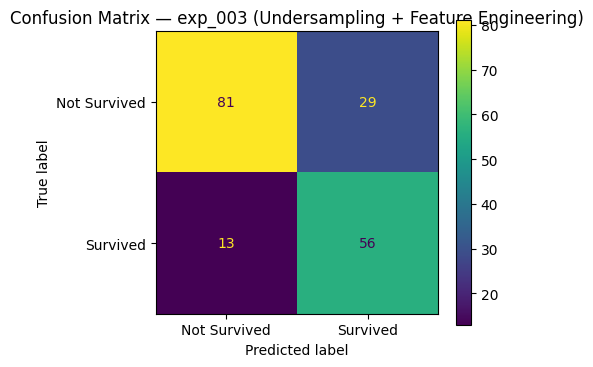

In [50]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test,
                                      display_labels=['Not Survived', 'Survived'], ax=ax)
plt.title('Confusion Matrix — exp_003 (Undersampling + Feature Engineering)')
plt.tight_layout()
plt.show()

## 7. Feature Importance — SHAP

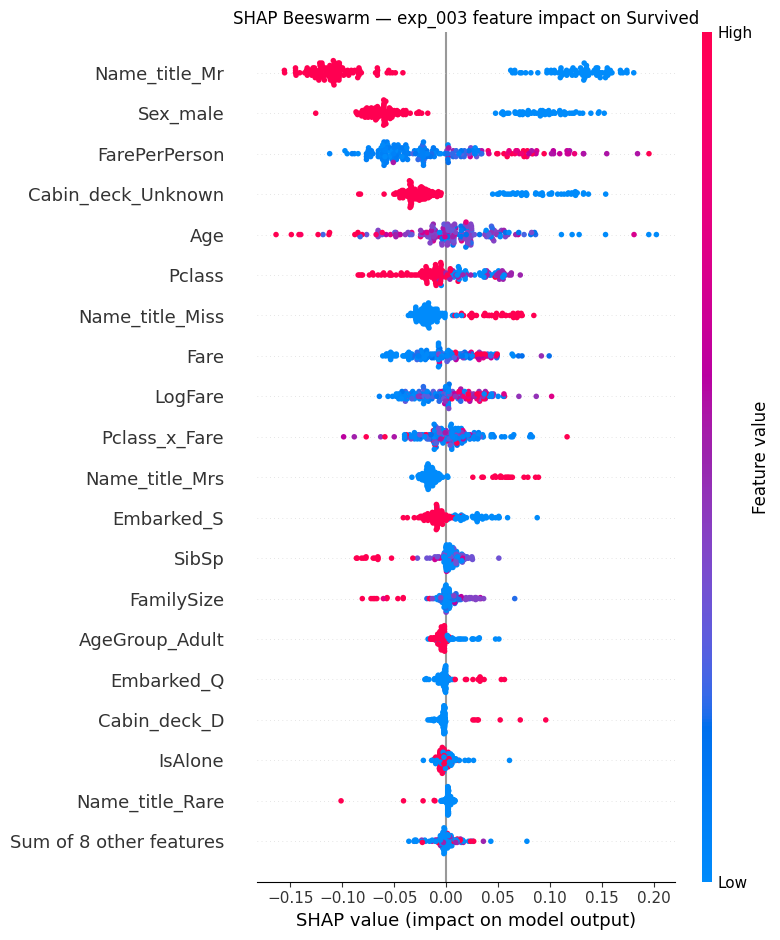

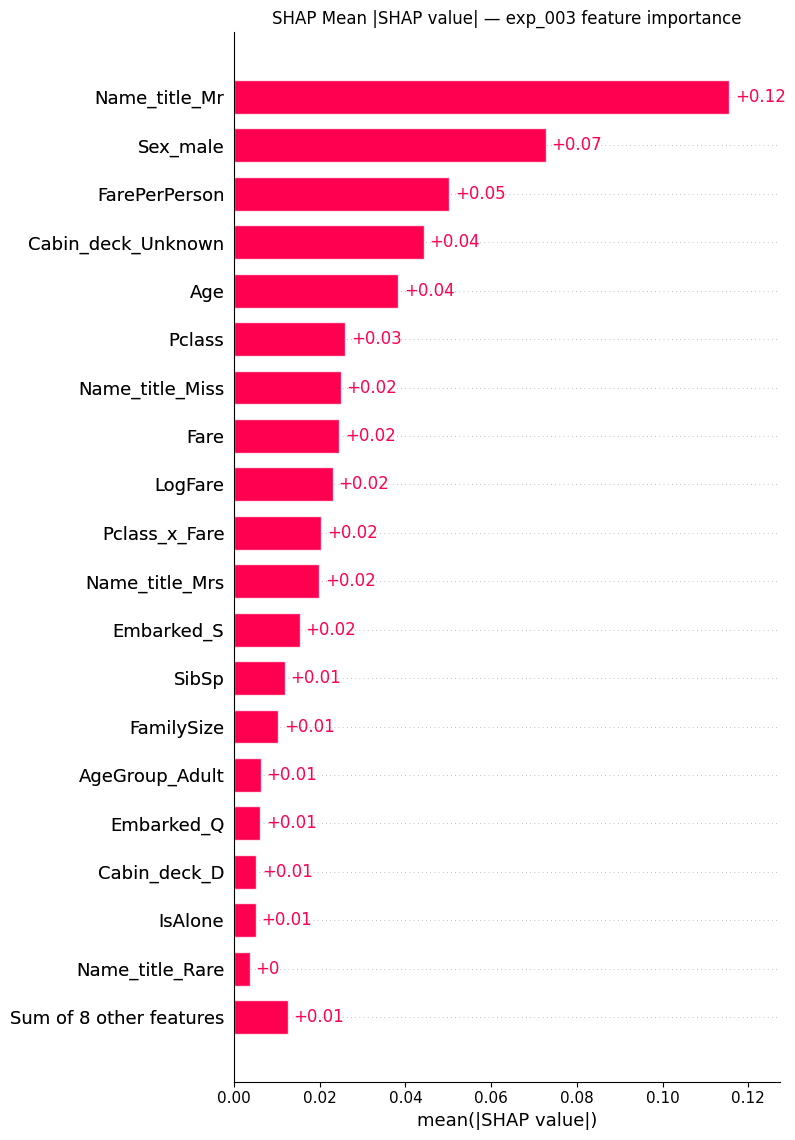

In [51]:
explainer   = shap.TreeExplainer(rf)
shap_values = explainer(X_test)
sv = shap_values[..., 1]

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title('SHAP Beeswarm — exp_003 feature impact on Survived')
plt.tight_layout()
plt.show()

shap.plots.bar(sv, max_display=20, show=False)
plt.title('SHAP Mean |SHAP value| — exp_003 feature importance')
plt.tight_layout()
plt.show()

# Experiment results comparison

| Experiment | CV AUC | Hold-out AUC | Precision (Survived) | Recall (Survived) | F1 (Survived) | Accuracy |
|---|---|---|---|---|---|---|
| exp_001 Baseline | 0.8741 | 0.8282 | 0.75 | 0.68 | 0.71 | 0.79 |
| exp_002 Undersample | 0.8724 | 0.8237 | 0.63 | 0.77 | 0.69 | 0.74 |
| exp_003 FE + Undersample | 0.8727 | 0.8216 | 0.66 | 0.81 | 0.73 | 0.77 |